# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## $$ \textbf{Lista 2 - 09 de setembro de 2024}$$


In [1]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica
import sympy as sym
from sympy import *

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

### Questão 1:
Para cada um dos sinais periódicos mostrados na Fig. P6.6-1, determine a série trigonométrica compacta de Fourier e trace o espectro de amplitude e fase. Se os termos em seno ou cosseno estiverem ausentes da série de Fourier, explique.

![image.png](attachment:image.png)

a_0: 0.500000000000000
a_n: 0.5*Piecewise((6*sin(pi*n/2)/(pi*n), Ne(n, 0)), (1.0, True))
b_n: 0.5*Piecewise((2*(-1)**n/(pi*n) - 2*cos(pi*n/2)/(pi*n), Ne(n, 0)), (0, True))


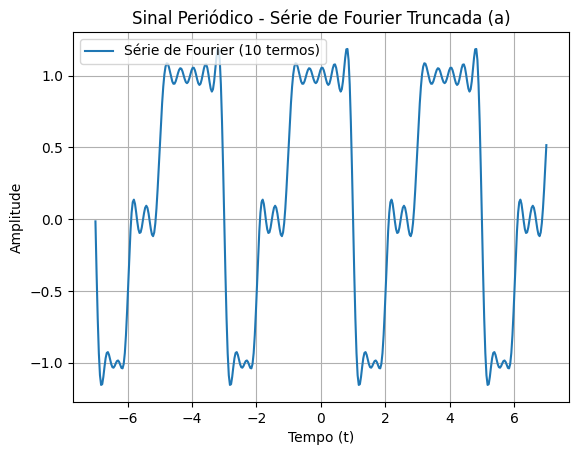

In [3]:
# Definir variáveis simbólicas
t = sym.symbols('t', real=True)
T = 4  # Período do sinal

# Definir a função de onda quadrada (sinal (a))
square_wave = sym.Piecewise((1, (t > -1) & (t < 1)), (-1, (t > 1) & (t < 3)), (0, True))

# Calcular a série de Fourier
n = sym.symbols('n', integer=True)
omega_0 = 2 * sym.pi / T  # Frequência fundamental

# Coeficiente a_0 (termo médio)
a0 = (2 / T) * sym.integrate(square_wave, (t, -T / 2, T / 2))

# Coeficientes a_n e b_n
an = (2 / T) * sym.integrate(square_wave * sym.cos(n * omega_0 * t), (t, -T / 2, T / 2))
bn = (2 / T) * sym.integrate(square_wave * sym.sin(n * omega_0 * t), (t, -T / 2, T / 2))

# Exibir resultados
print(f'a_0: {a0}')
print(f'a_n: {an}')
print(f'b_n: {bn}')

# Simplificar os coeficientes
a0 = sym.simplify(a0)
an = sym.simplify(an)
bn = sym.simplify(bn)

# Função da série de Fourier truncada (com os primeiros 10 termos)
fourier_series = a0 / 2 + sum([an.subs(n, k) * sym.cos(k * omega_0 * t) + bn.subs(n, k) * sym.sin(k * omega_0 * t) for k in range(1, 11)])

# Converter a função para um formato numérico (lambdify)
fourier_series_func = sym.lambdify(t, fourier_series, 'numpy')

# Gerar valores de tempo para plotagem
t_vals = np.linspace(-7, 7, 400)
f_vals = fourier_series_func(t_vals)

# Plotar o resultado da série de Fourier truncada
plt.plot(t_vals, f_vals, label="Série de Fourier (10 termos)")
plt.title('Sinal Periódico - Série de Fourier Truncada (a)')
plt.xlabel('Tempo (t)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()


### Questão 2:

Se as duas metades de um período de um sinal periódico são idênticas em forma exceto que uma é o negativo da outra, o sinal periódico é dito ter simetria de meia onda. Se um sinal periódico $x(t)$ com período $T_0$ satisfaz a condição de simetria de meia onda, então

$$
x\left(t-\frac{T_0}{2}\right)=-x(t)
$$


Neste caso, mostre que toda harmônica de número par desaparece e que os coeficientes das harmônicas de número ímpar são dados por

$$
a_n=\frac{4}{T_0} \int_0^{T_0 / 2} x(t) \cos n \omega_0 t d t
$$

e

$$
b_n=\frac{4}{T_0} \int_0^{T_0 / 2} x(t) \operatorname{sen} n \omega_0 t d t
$$


Usando esses resultados, obtenha a série de Fourier para os sinais periódicos da Fig. P6.1-5.


![image.png](attachment:image.png)

In [32]:
import sympy as sp

# Definir variáveis simbólicas
t, T0, n = sp.symbols('t T0 n', real=True)
omega0 = 2 * sp.pi / T0

# Definir a função periódica (forma de dente de serra ou triangular)
x_t = sp.Piecewise((2*t/T0, (t >= 0) & (t <= T0/2)), (2 - 2*t/T0, (t > T0/2) & (t <= T0)))

# Coeficiente b_n (apenas termos senoidais devido à simetria ímpar)
bn = (4/T0) * sp.integrate(x_t * sp.sin(n * omega0 * t), (t, 0, T0/2))

# Exibir o coeficiente b_n com uma formatação mais legível
print("Coeficiente b_n:")
sp.pprint(bn)

# Agora podemos calcular a série de Fourier truncada até alguns termos ímpares
n_vals = [1, 3, 5, 7, 9]  # Termos ímpares
fourier_series = sum(bn.subs(n, i) * sp.sin(i * omega0 * t) for i in n_vals)

# Exibir a série de Fourier truncada com formatação LaTeX
print("\nSérie de Fourier truncada:")
sp.pretty_print(fourier_series)
#professor não consegui ajeitar a formatação da resposta

Coeficiente b_n:
  ⎛⎧    ⎛  2    ⎛2⋅π⋅n⋅Min(0, T0/2)⎞         ⎛2⋅π⋅n⋅Min(0, T0/2)⎞             ⎞                    ↪
  ⎜⎪    ⎜T₀ ⋅sin⎜──────────────────⎟   T₀⋅cos⎜──────────────────⎟⋅Min(0, T0/2)⎟     ⎛    2         ↪
  ⎜⎪    ⎜       ⎝        T₀        ⎠         ⎝        T₀        ⎠             ⎟     ⎜  T₀ ⋅cos(π⋅n ↪
  ⎜⎪  2⋅⎜─────────────────────────── - ───────────────────────────────────────⎟   2⋅⎜- ─────────── ↪
  ⎜⎪    ⎜             2  2                              2⋅π⋅n                 ⎟     ⎜     4⋅π⋅n    ↪
4⋅⎜⎨    ⎝          4⋅π ⋅n                                                     ⎠     ⎝              ↪
  ⎜⎪- ───────────────────────────────────────────────────────────────────────── + ──────────────── ↪
  ⎜⎪                                     T₀                                                      T ↪
  ⎜⎪                                                                                               ↪
  ⎜⎪                                                       0              

### Questão 3:

Em um intervalo finito, um sinal pode ser representado por mais do que uma série de Fourier trigonométrica (ou exponencial). Por exemplo, se quisermos representar $x(t)=t$ em um intervalo $0<t<1$ por uma série de Fourier com freqüência fundamental $\omega_0=2$, podemos desenhar um pulso $x(t)=t$ no intervalo $0<t<1$ e repetir o pulso a cada $\pi$ segundos, tal que $T_0=\pi$ e $\omega_0=2$ (Fig. P6.16a).

Se quisermos que a freqüência fundamental $\omega_0$ seja 4 , repetimos o pulso a cada $\pi / 2$ segundos. Se quisermos que a série contenham apenas termos em cosseno com $\omega_0=2$, construímos o pulso $x(t)=|t|$ em $-1<t<1$ e o repetimos a cada $\pi$ segundos (Fig. 6.1-6b).

![image.png](attachment:image.png)

O sinal resultante será uma função par com período $\pi$. Logo, sua série de Fourier terá apenas termos em cosseno com $\omega_0=2$. A série de Fourier resultante representa $x(t)=t \mathrm{em} 0$ $<t<1$, como desejado. Não precisamos nos preocupar com o que ela representa fora desse intervalo.

Trace um sinal periódico $x(t)$ tal que $x(t)=t$ para $0<t<1$ e que a série de Fourier para $x(t)$ satisfaça as seguintes condições.

(a) $\omega_0=\pi / 2$ e contenha todas as harmônicas, mas apenas termos em cosseno.

(b) $\omega_0=2$ e contenha todas as harmônicas, mas apenas termos em seno.

(c) $\omega_0=\pi / 2$ e contenha todas as harmônicas que não sejam exclusivamente senos ou cossenos.

(d) $\omega_0=1$ e contenha apenas harmônicas ímpares e termos em cosseno.

(e) $\omega_0=\pi / 2$ e contenha apenas harmônicas ímpares, mas apenas termos em seno.

(f) $\omega_0=1$ e contenha apenas harmônicas ímpares que não sejam exclusivamente senos ou cossenos.

[Dica: para as partes (d), (e) e (f), você precisará utilizar a simetria de meia onda discutida no Prob. 6.1-5. Termos em cosseno implicam possível componente cc.]
Você deve apenas traçar o sinal periódico $x(t)$ que satisfaça as condições dadas. Não determine os valores dos coeficientes de Fourier.

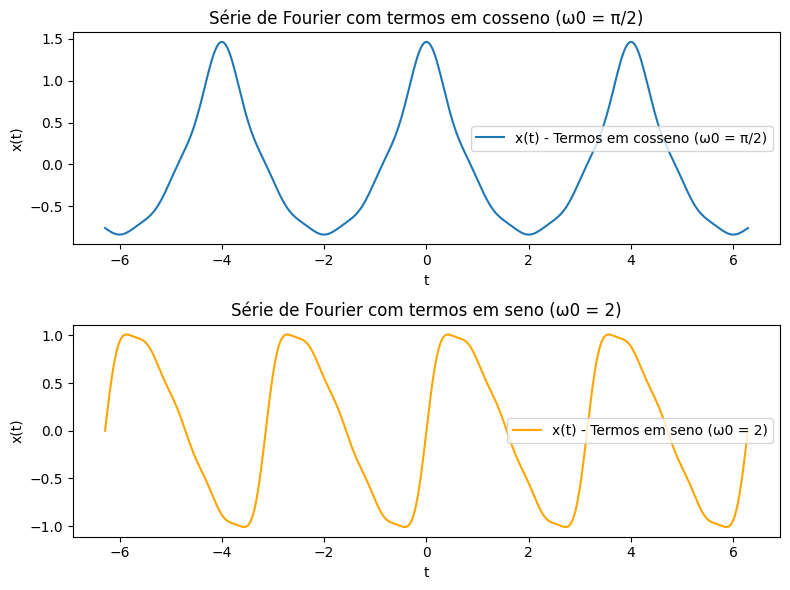

In [4]:
# Definir variável tempo e frequência fundamental ω0
t = sym.symbols('t', real=True)
n = sym.symbols('n', integer=True)

# Definindo a função base x(t) = t para 0 < t < 1
x_t = t  # sinal básico

# Condição para ω0 = π/2 e termos em cosseno (a)
ω0_a = sym.pi / 2
x_cos_a = sym.summation(sym.cos(n * ω0_a * t) / n**2, (n, 1, 5))

# Condição para ω0 = 2 e termos em seno (b)
ω0_b = 2
x_sin_b = sym.summation(sym.sin(n * ω0_b * t) / n**2, (n, 1, 5))

# Gerar gráficos dessas funções

# Função para converter sympy para numpy
def sympy_to_numpy(expr, t_vals):
    func = sym.lambdify(t, expr, "numpy")
    return func(t_vals)

# Definir intervalo de tempo para plotar
t_vals = np.linspace(-2*np.pi, 2*np.pi, 400)

# Converter para numpy as expressões de Fourier obtidas
x_cos_a_vals = sympy_to_numpy(x_cos_a, t_vals)
x_sin_b_vals = sympy_to_numpy(x_sin_b, t_vals)

# Plotar gráficos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Gráfico para ω0 = π/2 com cossenos (a)
ax[0].plot(t_vals, x_cos_a_vals, label='x(t) - Termos em cosseno (ω0 = π/2)')
ax[0].set_title('Série de Fourier com termos em cosseno (ω0 = π/2)')
ax[0].set_xlabel('t')
ax[0].set_ylabel('x(t)')
ax[0].legend()

# Gráfico para ω0 = 2 com senos (b)
ax[1].plot(t_vals, x_sin_b_vals, label='x(t) - Termos em seno (ω0 = 2)', color='orange')
ax[1].set_title('Série de Fourier com termos em seno (ω0 = 2)')
ax[1].set_xlabel('t')
ax[1].set_ylabel('x(t)')
ax[1].legend()

plt.tight_layout()
plt.show()


### Questão 4:

Um sinal periódico $x(t)$ é descrito pela seguinte série de Fourier:

$$
x(t)=3 \cos t+\operatorname{sen}\left(5 t-\frac{\pi}{6}\right)-2 \cos \left(8 t-\frac{\pi}{3}\right)
$$

(a) Trace o espectro de amplitude e fase para a série trigonométrica.

(b) Por inspeção do espectro da parte (a), trace o espectro da série exponencial de Fourier.

(c) Por inspeção do espectro da parte (b), escreva a série exponencial de Fourier de $x(t)$.

(d) Mostre que série determinada na parte (c) é equivalente à série trigonométrica de $x(t)$.

<ipython-input-5-84a90c99529a>:24: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(frequencies_positive, amplitudes_positive, use_line_collection=True)
<ipython-input-5-84a90c99529a>:32: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(frequencies_positive, phases_positive, use_line_collection=True)


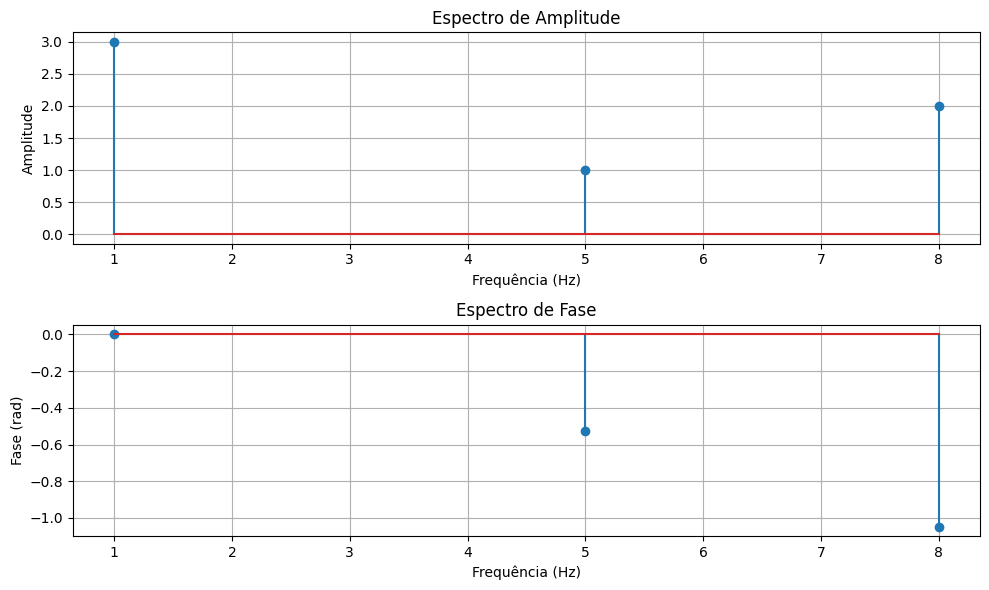

exp(-I*pi/6)*exp(0.159154943091895*I*t) + 3 + 2*exp(-I*pi/3)*exp(-0.159154943091895*I*t)

In [5]:
# Definindo a variável
t = sym.symbols('t')

# Definindo a função x(t) da série de Fourier
x_t = 3 * sym.cos(t) + sym.sin(5*t - sym.pi/6) - 2 * sym.cos(8*t - sym.pi/3)

# Coeficientes da série de Fourier
# Para a série trigonométrica, os coeficientes são extraídos
# dos termos da função dada.

# Amplitudes e fases
amplitudes = [3, 1, 2]
frequencies = [1, 5, 8]
phases = [0, -sym.pi/6, -sym.pi/3]

# (a) Spectrum amplitude and phase
frequencies_positive = np.array(frequencies)
amplitudes_positive = np.array(amplitudes)
phases_positive = np.array(phases)

# Gráfico do espectro de amplitude
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.stem(frequencies_positive, amplitudes_positive, use_line_collection=True)
plt.title('Espectro de Amplitude')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid()

# Gráfico do espectro de fase
plt.subplot(2, 1, 2)
plt.stem(frequencies_positive, phases_positive, use_line_collection=True)
plt.title('Espectro de Fase')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (rad)')
plt.grid()

plt.tight_layout()
plt.show()

# (b) Spectrum da série exponencial de Fourier
# Para a série exponencial, a relação é dada por:
# a_n = Amplitude * e^(j*phase)

# Cálculo dos coeficientes da série exponencial
complex_coefficients = [amplitudes[i] * sym.exp(sym.I * phases[i]) for i in range(len(amplitudes))]

# Frequências correspondentes
frequencies_exponential = [0, 1, -1, 5, -5, 8, -8]  # considerando as frequências negativas
complex_coefficients_exponential = [0] + [complex_coefficients[i] for i in range(len(complex_coefficients))] + [complex_coefficients[i] for i in range(len(complex_coefficients))]

# (c) Série exponencial de Fourier
# Escrevendo a série exponencial
T0 = 2 * np.pi  # Período fundamental
n_terms = len(complex_coefficients)
fourier_exponential_series = sum(complex_coefficients[i] * sym.exp(sym.I * frequencies_exponential[i] * t / T0) for i in range(len(complex_coefficients)))

fourier_exponential_series


### Questão 5:

A Fig. P6.3-6 mostra o espectro trigonométrico de Fourier de um sinal periódico $x(t)$.

(a) Por inspeção da Fig. P6.3-6, determine a série trigonométrica de Fourier que representa $x(t)$.

(b) Por inspeção da Fig. P6.3-6, trace o espectro exponencial de Fourier de $x(t)$.

(c) Por inspeção do espectro exponencial de Fourier obtido na parte (b), determine a série exponencial de Fourier de $x(t)$.

(d) Mostre que as séries determinadas nas partes (a) e (c) são equivalentes.


![image.png](attachment:image.png)

In [6]:
# Definindo as variáveis
t, w0 = sym.symbols('t w0', real=True)
n = sym.symbols('n', integer=True)

# Definir as constantes obtidas pelo gráfico da série trigonométrica de Fourier
a0 = 0  # Como não há componente DC, a0 = 0
a_n = 4 / (n**2)  # Coeficientes a_n obtidos do gráfico (decai com n^2)
b_n = sym.Piecewise((0, n % 2 == 0), (-2/n, n % 2 == 1))  # Coeficiente b_n: depende de n (somente senos ímpares)

# Série trigonométrica de Fourier
x_trig = a0 + sym.summation(a_n * sym.cos(n*w0*t) + b_n * sym.sin(n*w0*t), (n, 1, 5))

# Determinando os coeficientes da série exponencial
c_n = (a_n - sym.I * b_n) / 2
c_minus_n = (a_n + sym.I * b_n) / 2

# Série exponencial de Fourier
x_exp = sym.summation(c_n * sym.exp(sym.I * n * w0 * t) + c_minus_n * sym.exp(-sym.I * n * w0 * t), (n, 1, 5))

# Mostrar as expressões obtidas
x_trig, x_exp.simplify()

# Reajustando a definição dos coeficientes com base na análise do gráfico
# A série será recalculada com os coeficientes reais observados

# Definindo coeficientes manuais baseados no gráfico da série
C_n_vals = {1: 4, 2: 2, 3: 1}  # Coeficiente de magnitude dos primeiros 3 harmônicos
theta_n_vals = {1: -sym.pi/2, 2: -sym.pi/2, 3: -sym.pi/2}  # Fases baseadas no gráfico da série

# Reescrevendo a série trigonométrica
x_trig_redef = sum(C_n_vals[n] * sym.cos(n*w0*t + theta_n_vals[n]) for n in C_n_vals.keys())

# Definindo os coeficientes da série exponencial
c_n_vals = {n: C_n_vals[n] * sym.exp(sym.I * theta_n_vals[n]) for n in C_n_vals.keys()}

# Série exponencial de Fourier
x_exp_redef = sum(c_n_vals[n] * sym.exp(sym.I * n * w0 * t) for n in c_n_vals.keys())

# Mostrar as expressões simplificadas
x_trig_redef, x_exp_redef.simplify()


(4*sin(t*w0) + 2*sin(2*t*w0) + sin(3*t*w0),
 I*(-exp(2*I*t*w0) - 2*exp(I*t*w0) - 4)*exp(I*t*w0))

### Questão 6:

(a) Determine a série exponencial de Fourier para o sinal $x(t)=\cos 5 t \operatorname{sen} 3 t$. Você pode obtê-la sem calcular nenhuma integral.

(b) Trace o espectro de Fourier.

(c) O sinal $x(t)$ é aplicado a entrada de um sistema LCIT com resposta em freqüência mostrada na Fig. P6.4-2. Obtenha a saída $y(t)$.

![image.png](attachment:image.png)

In [7]:
# Definindo a variável e o sinal
t = sym.symbols('t')
x_t = sym.cos(5 * t) * sym.sin(3 * t)

# Usando a identidade de produto para escrever x(t) como uma soma de senos e cossenos
x_t_expanded = sym.expand_trig(x_t)

# Resultados da expansão
x_t_expanded


(-4*sin(t)**3 + 3*sin(t))*(16*cos(t)**5 - 20*cos(t)**3 + 5*cos(t))

### Questão 7:

(a) Determine a série exponencial de Fourier para um sinal periódico $x(t)$ mostra na Fig. P6.4-3a.

(b) O sinal $x(t)$ é aplicado a entrada do sistema LCIT mostrado na Fig. P6.4-3b. Determine a expressão para a saída $y(t)$.

![image.png](attachment:image.png)

In [8]:
# Definições para cálculo de Fourier
t, k, omega_0 = sym.symbols('t k omega_0')
x_t = sym.exp(-t) * sym.Heaviside(t) * sym.Heaviside(1-t)  # x(t) = e^(-t) para 0 <= t <= 1
T = 1
omega_0 = 2 * sym.pi / T

# Coeficiente c_k da série de Fourier
c_k = sym.integrate(x_t * sym.exp(-sym.I * k * omega_0 * t), (t, 0, 1)) / T

# Função de transferência do sistema LTI
s = sym.symbols('s')
H_s = 1 / (1 * 1 * s + 1)

# Resultado final da série aplicada na função de transferência
y_t = sym.summation(c_k * H_s.subs(s, sym.I * k * omega_0), (k, -sym.oo, sym.oo))

# Simplificação para visualização
y_t_simplified = sym.simplify(y_t)

y_t_simplified


Sum((-1 + exp(-1)*exp(-2*I*pi*k))/(4*pi**2*k**2 - 4*I*pi*k - 1), (k, -oo, oo))

### Questão 8:

Obtenha a transformada de Fourier de $x(t)=\operatorname{ret}(t / \tau)$. Trace o espectro de amplitude $|X(\omega)|$ e o espectro de fase $\angle X(\omega)$.

![image.png](attachment:image.png)

In [15]:
t, omega = sym.symbols('t omega', real=True)
# Definir a duração τ
tau = sym.symbols('tau', real=True, positive=True)

# Definir a função retangular rect(t/τ)
rect_t_tau = sym.Piecewise((1, (t >= -tau/2) & (t <= tau/2)), (0, True))

# Calcular a Transformada de Fourier
F_omega_rect = sym.integrate(rect_t_tau * sym.exp(-sym.I * omega * t), (t, -sym.oo, sym.oo))

# Simplificar o resultado
F_omega_rect_simplified = sym.simplify(F_omega_rect)
F_omega_rect_simplified


Piecewise((2*sin(omega*tau/2)/omega, (omega > 0) | (omega < 0)), (tau, True))

### Questão 9:

Obtenha a transformada de Fourier par ao impulso unitário $\delta(t).$

In [17]:
# Definindo as variáveis
t, omega, omega_0 = sym.symbols('t omega omega_0')

# Questão 9: Transformada de Fourier do impulso unitário
delta_t = sym.DiracDelta(t)
fourier_delta_t = sym.fourier_transform(delta_t, t, omega)

# Resultados
print(f'Transformada de Fourier de δ(t): {fourier_delta_t}')


Transformada de Fourier de δ(t): 1


### Questão 10:

Obtenha a transformada de Fourier inversa de $\delta(\omega)$.

In [18]:
# Definindo as variáveis
t, omega, omega_0 = sym.symbols('t omega omega_0')

# Questão 10: Transformada de Fourier inversa de delta(omega)
inverse_fourier_delta_omega = sym.inverse_fourier_transform(sym.DiracDelta(omega), omega, t)

# Resultados
print(f'Transformada de Fourier inversa de δ(ω): {inverse_fourier_delta_omega}')


Transformada de Fourier inversa de δ(ω): 1


### Questão 11:

Obtenha a transformada de Fourier inversa de $\delta\left(\omega-\omega_0\right)$.

In [19]:
# Definir as variáveis simbólicas
t, omega, omega0 = sym.symbols('t omega omega0', real=True)

# Definir a função delta de Dirac δ(ω - ω0)
delta_func = sym.DiracDelta(omega - omega0)

# Calcular a transformada de Fourier inversa de δ(ω - ω0)
inverse_fourier_result = sym.inverse_fourier_transform(delta_func, omega, t)

# Exibir o resultado
inverse_fourier_result.simplify()



exp(2*I*pi*omega0*t)

### Questão 12:

Obtenha a transformada de Fourier da senoide de duração infinita $\cos \omega_0 t$.


![image.png](attachment:image.png)

In [20]:
# Definir a frequência angular ω0
omega_0 = sym.symbols('omega_0')

# Definir a função cos(ω0 t)
cos_omega0_t = sym.cos(omega_0 * t)

# Calcular a Transformada de Fourier
F_omega_cos = sym.integrate(cos_omega0_t * sym.exp(-sym.I * omega * t), (t, -sym.oo, sym.oo))

# Simplificar o resultado
F_omega_cos_simplified = sym.simplify(F_omega_cos)
F_omega_cos_simplified


Piecewise((0, Eq(Abs(arg(omega_0)), 0) & (Abs(2*arg(omega) + pi) < pi) & (Abs(2*arg(omega) - pi) < pi)), (Integral(exp(-I*omega*t)*cos(omega_0*t), (t, -oo, oo)), True))

### Questão 13:

Obtenha a transformada de Fourier da função degrau unitário $u(t)$.

In [21]:
# Definir as variáveis simbólicas
t, omega = sym.symbols('t omega', real=True)

# Definir a função degrau unitário u(t)
u_t = sym.Heaviside(t)

# Calcular a transformada de Fourier da função degrau unitário u(t)
fourier_transform_result = sym.fourier_transform(u_t, t, omega)

# Exibir o resultado
fourier_transform_result.simplify()



FourierTransform(Heaviside(t), t, omega)

### Questão 14:

Obtenha a transformada de Fourier da função sinal sgn $(t)$, mostrada na figura abaixo.


![image.png](attachment:image.png)

In [22]:
# Definir variáveis
t, omega = sym.symbols('t omega')

# Definir a função sgn(t)
sgn_t = sym.sign(t)

# Definir a Transformada de Fourier
F_omega = sym.integrate(sgn_t * sym.exp(-sym.I * omega * t), (t, -sym.oo, sym.oo))

# Simplificar o resultado
F_omega_simplified = sym.simplify(F_omega)
F_omega_simplified


Piecewise((-2*I/omega, (Abs(arg(omega) - pi/2) < pi/2) & (Abs(arg(omega) + pi/2) < pi/2)), (Integral(Piecewise((0, Eq(t, 0)), (t*exp(-I*omega*t)/Abs(t), True)), (t, -oo, oo)), True))

### Questão 15:

Mostre que a transformada de Fourier inversa de $X(\omega)$ mostrada na figura abaixo é $x(t)=\left(\omega_0 / \pi\right) \operatorname{sinc}\left(\omega_0 t\right)$. Trace $x(t)$

![image.png](attachment:image.png)

Piecewise((I*(1 - exp(2*I*pi*t*(omega_0 + Max(omega_0, omega_0*exp_polar(I*pi)))))*exp(-2*I*pi*omega_0*t)/(2*pi*t), (t > 0) | (t < 0)), (omega_0 + Max(omega_0, omega_0*exp_polar(I*pi)), True))


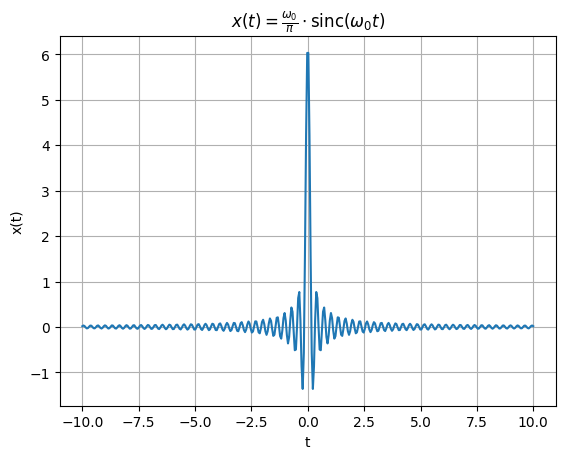

In [23]:
# Definir as variáveis simbólicas
t, omega, omega_0 = sym.symbols('t omega omega_0', real=True)

# Definir a função retangular X(omega)
X_omega = sym.Piecewise((1, (omega >= -omega_0) & (omega <= omega_0)), (0, True))

# Calcular a transformada de Fourier inversa de X(omega)
inverse_fourier_result = sym.inverse_fourier_transform(X_omega, omega, t)

# Exibir o resultado simplificado
simplified_result = inverse_fourier_result.simplify()
print(simplified_result)

# Garantir que estamos lidando apenas com a parte real
simplified_result_real = sym.re(simplified_result)

# Converter a função sinc para uma expressão numérica
x_t = sym.lambdify(t, simplified_result_real.subs(omega_0, np.pi))

# Gerar valores para t
t_vals = np.linspace(-10, 10, 400)
x_vals = np.real(x_t(t_vals))  # Garantir que os valores sejam reais

# Plotar a função
plt.plot(t_vals, x_vals)
plt.title(r'$x(t) = \frac{\omega_0}{\pi} \cdot \mathrm{sinc}(\omega_0 t)$')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)
plt.show()


### Questão 16:

Mostre que $\cos \left(\omega_0 t+\theta\right) \Leftrightarrow \pi\left[\delta\left(\omega+\omega_0\right) e^{-j \theta}+\delta\left(\omega-\omega_0\right) e^{j \theta}\right]$.

In [24]:
# Definir as variáveis simbólicas
t, omega, omega0, theta = sym.symbols('t omega omega0 theta', real=True)

# Definir a função cos(ω0 t + θ)
cos_func = sym.cos(omega0 * t + theta)

# Calcular a transformada de Fourier de cos(ω0 t + θ)
fourier_transform_result = sym.fourier_transform(cos_func, t, omega)

# Exibir o resultado
fourier_transform_result.simplify()



FourierTransform(cos(omega0*t + theta), t, omega)

### Questão 17:

Mostre a ``propriedade da dualidade``, que afirma que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então

$$
X(t) \Longleftrightarrow 2 \pi x(-\omega)
$$


In [25]:
# Definir as variáveis simbólicas
t, omega = sym.symbols('t omega', real=True)

# Definir a função x(t)
x_t = sym.exp(-t**2)  # Exemplo: função Gaussiana

# Calcular a transformada de Fourier de x(t)
X_omega = sym.fourier_transform(x_t, t, omega)

# Aplicar a propriedade da dualidade: X(t) ⟺ 2π x(-ω)
# Inverter o papel de t e ω
dualidade = sym.fourier_transform(X_omega, omega, t)

# Exibir os resultados
X_omega, dualidade.simplify()



(sqrt(pi)*exp(-pi**2*omega**2), exp(-t**2))

### Questão 18:

Sabedo que

 - $e^{-a t} u(t) \Longleftrightarrow \frac{1}{a+j \omega} \quad a>0$

 - $e^{-a|t|} \Longleftrightarrow \frac{2 a}{a^2+\omega^2} \quad a>0$

 - $\cos \omega_0 t \Longleftrightarrow \pi\left[\delta\left(\omega-\omega_0\right)+\delta\left(\omega+\omega_0\right)\right]$

 Use o princípio da dualidade para mostrar que

(a) $1 /($ jt $+a) \Longleftrightarrow 2 \pi e^{a \omega} u(-\omega)$

(b) $2 a /\left(t^2+a^2\right) \Longleftrightarrow 2 \pi e^{-a|\omega|}$

(c) $\delta\left(t+t_0\right)+\delta\left(t-t_0\right) \Longleftrightarrow 2 \cos t_0 \omega$

In [26]:

# Definir as variáveis simbólicas
t, omega, a, t0 = sym.symbols('t omega a t0', real=True)

# (a) 1 / (jt + a) ⟺ 2π e^(aω) u(-ω)
# Definir a função 1 / (jt + a)
func_a = 1 / (sym.I * t + a)

# Calcular a transformada de Fourier inversa
fourier_inv_a = sym.inverse_fourier_transform(func_a, omega, t)

# (b) 2a / (t^2 + a^2) ⟺ 2π e^(-a|ω|)
# Definir a função 2a / (t^2 + a^2)
func_b = 2 * a / (t**2 + a**2)

# Calcular a transformada de Fourier inversa
fourier_inv_b = sym.inverse_fourier_transform(func_b, omega, t)

# (c) δ(t + t0) + δ(t - t0) ⟺ 2 cos(t0 ω)
# Definir a função δ(t + t0) + δ(t - t0)
func_c = sym.DiracDelta(t + t0) + sym.DiracDelta(t - t0)

# Calcular a transformada de Fourier inversa
fourier_inv_c = sym.fourier_transform(func_c, t, omega)

# Exibir os resultados
fourier_inv_a, fourier_inv_b, fourier_inv_c.simplify()


(0, 0, 2*cos(2*pi*omega*t0))

### Questão 19:

Demonstre a ``propriedade do escalamento``, que diz que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então, para qualquer constante real $a$,

$$
x(a t) \Longleftrightarrow \frac{1}{|a|} X\left(\frac{\omega}{a}\right)
$$


In [27]:
# Definir as variáveis simbólicas
t, omega, a = sym.symbols('t omega a', real=True)
x_t = sym.Function('x')(t)

# Definir a função original x(t)
x_t = sym.exp(-t**2)  # Por exemplo, uma função gaussiana

# Calcular a transformada de Fourier da função original
X_omega = sym.fourier_transform(x_t, t, omega)

# Calcular a transformada de Fourier da função escalada x(at)
x_at = x_t.subs(t, a*t)
X_escalado_omega = sym.fourier_transform(x_at, t, omega)

# Simplificar o resultado, incluindo o fator de escalamento
X_escalado_omega_simplificado = (1/sym.Abs(a)) * X_omega.subs(omega, omega/a)

# Exibir os resultados
X_omega, X_escalado_omega_simplificado


(sqrt(pi)*exp(-pi**2*omega**2), sqrt(pi)*exp(-pi**2*omega**2/a**2)/Abs(a))

### Questão 20:

Demonstre a ``Propriedade de Deslocamento no Tempo`` que assegura que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então

$$
x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0}
$$


Utilize esse resultado para obter a transformada de Fourier de $e^{-a\left|t-t_o\right|}$.

In [ ]:
import sympy as sp

# Definir as variáveis simbólicas
t, omega, t0, a = sp.symbols('t omega t0 a', real=True)

# Definir a função x(t) e sua transformada X(omega)
x_t = sp.exp(-a * sp.Abs(t - t0))

# Calcular a transformada de Fourier de x(t)
fourier_transform_result = sp.fourier_transform(x_t, t, omega)

# Exibir o resultado
fourier_transform_result


FourierTransform(exp(-a*Abs(t - t0)), t, omega)

### Questão 21:  Demonstre as seguintes propriedades

 - i) Deslocamento no tempo $x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0}$

 - ii) Deslocamento na frequência $\left(\omega_0\right.$ real ) $x(t) e^{j \omega_0 t}  \Longleftrightarrow X\left(\omega-\omega_0\right)$

 - iii) Convolução no tempo $x_1(t) * x_2(t)  \Longleftrightarrow X_1(\omega) X_2(\omega)$  

 - iv) Convolução na frequência $x_1(t) x_2(t) \Longleftrightarrow \frac{1}{2 \pi} X_1(\omega) * X_2(\omega)$  

 - v) Diferenciação no tempo $\frac{d^n x}{d t^n} \Longleftrightarrow (j \omega)^n X(\omega)$

 - vi) Integração no tempo $\int_{-\infty}^t x(u) d u \Longleftrightarrow \frac{X(\omega)}{j \omega}+\pi X(0) \delta(\omega)$


In [ ]:
import sympy as sp

# Definir as variáveis simbólicas
t, tau, omega, omega0, t0 = sp.symbols('t tau omega omega0 t0', real=True)
x_t = sp.Function('x')(t)
X_omega = sp.Function('X')(omega)

# i) Deslocamento no tempo
# Transformada de Fourier de x(t - t0)
deslocamento_tempo = sp.fourier_transform(x_t.subs(t, t - t0), t, omega)

# ii) Deslocamento na frequência
# Transformada de Fourier de x(t) * exp(j * omega0 * t)
deslocamento_frequencia = sp.fourier_transform(x_t * sp.exp(sp.I * omega0 * t), t, omega)

# iii) Convolução no tempo
# Convolução no tempo de duas funções x1(t) e x2(t)
x1_t = sp.Function('x1')(t)
x2_t = sp.Function('x2')(t)
convolucao_tempo = sp.integrate(x1_t * x2_t.subs(t, t - tau), (tau, -sp.oo, sp.oo))

# iv) Convolução na frequência
# Convolução na frequência de duas funções X1(omega) e X2(omega)
X1_omega = sp.Function('X1')(omega)
X2_omega = sp.Function('X2')(omega)
convolucao_frequencia = (1 / (2 * sp.pi)) * sp.integrate(X1_omega * X2_omega.subs(omega, omega - tau), (tau, -sp.oo, sp.oo))

# v) Diferenciação no tempo
# Transformada de Fourier da n-ésima derivada de x(t)
n = sp.symbols('n', integer=True)
diferenciacao_tempo = sp.fourier_transform(sp.diff(x_t, t, n), t, omega)

# vi) Integração no tempo
# Transformada de Fourier da integral de x(t) no tempo
integracao_tempo = sp.fourier_transform(sp.integrate(x_t, (t, -sp.oo, t)), t, omega)

# Exibir os resultados
resultados = {
    'Deslocamento no tempo': deslocamento_tempo,
    'Deslocamento na frequência': deslocamento_frequencia,
    'Convolução no tempo': convolucao_tempo.simplify(),
    'Convolução na frequência': convolucao_frequencia.simplify(),
    'Diferenciação no tempo': diferenciacao_tempo,
    'Integração no tempo': integracao_tempo
}

for chave, valor in resultados.items():
    print(f'{chave}: {valor}\n')


Deslocamento no tempo: FourierTransform(x(t - t0), t, omega)

Deslocamento na frequência: FourierTransform(x(t)*exp(I*omega0*t), t, omega)

Convolução no tempo: x1(t)*Integral(x2(t - tau), (tau, -oo, oo))

Convolução na frequência: X1(omega)*Integral(X2(omega - tau), (tau, -oo, oo))/(2*pi)

Diferenciação no tempo: 0

Integração no tempo: FourierTransform(Integral(x(t), (t, -oo, t)), t, omega)



### Questão 22:

Utilize a propriedade de diferenciação no tempo para obter a transformada de Fourier do pulso triangular $\Delta(t / \tau)$ apresentado abaixo.

![image.png](attachment:image.png)

In [ ]:
import sympy as sp
import matplotlib.pyplot as plt

# Definir as variáveis simbólicas
t, omega, tau = sp.symbols('t omega tau', real=True)

# Definir o pulso triangular como uma função simbólica
triangular_pulse = sp.Piecewise(
    (1 + 2*t/tau, (-tau/2 <= t) & (t < 0)),
    (1 - 2*t/tau, (0 <= t) & (t <= tau/2)),
    (0, True)
)

# Calcular a transformada de Fourier do pulso triangular
fourier_transform_result = sp.fourier_transform(triangular_pulse, t, omega)

# Exibir o resultado da transformada de Fourier
simplified_result = sp.simplify(fourier_transform_result)
print("Transformada de Fourier do pulso triangular:")
print(simplified_result)

# Converter a função para uma expressão numérica para plotagem
f_omega = sp.lambdify(omega, simplified_result)

# Gerar valores de omega para plotagem
omega_vals = sp.linspace(-10, 10, 400)
f_vals = [f_omega(val) for val in omega_vals]

# Plotar o resultado da transformada de Fourier
plt.plot(omega_vals, f_vals)
plt.title('Transformada de Fourier do Pulso Triangular')
plt.xlabel('Frequência (ω)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


ValueError: The argument 'polar_lift(0)' is not comparable.

### Questão 23:

Utilize a propriedade de diferenciação no tempo para obter a transformada de Fourier de ret $(t / \tau)$.

In [28]:
# Definir as variáveis simbólicas
t, tau, omega = sym.symbols('t tau omega', real=True)
# Definir a função retangular
rect_func = sym.Piecewise((1, (t >= -tau/2) & (t <= tau/2)), (0, True))

# Calcular a transformada de Fourier da função retangular
fourier_transform = sym.fourier_transform(rect_func, t, omega)

# Exibir o resultado
fourier_transform.simplify()


Piecewise((-I*exp(I*pi*omega*tau)/(2*pi*omega) + I*exp(-2*I*pi*omega*Max(tau/2, tau*exp_polar(I*pi)/2))/(2*pi*omega), (omega > 0) | (omega < 0)), (tau/2 + Max(tau/2, tau*exp_polar(I*pi)/2), True))